# Support Vector Machine (SVM) Analysis

This Notebook applies Support Vector Machine classification with GridSearchCV to all three datasets:
1. **Telco Customer Churn** - Predicting customer churn
2. **Online Shoppers Intention** - Predicting purchase intention
3. **Bank Marketing** - Predicting term deposit subscription

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn import preprocessing
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score, classification_report
)

RANDOM_STATE = 42
PARAM_GRID = {'C': [0.01,0.1, 1, 10]}
TELCO_PATH = "../data/processed/telco_clean.csv"
BANK_PATH = "../data/processed/bank_clean.csv"
ECOM_PATH = "../data/processed/ecom_clean.csv"


def sort_bank_temporally(df):
    """Sort Bank Marketing rows chronologically by month and day_of_week.

    Mirrors src/evaluation.py's sort_dataframe_temporally so the Bank
    train/test split below matches the leak-safe temporal split used for
    Gradient Boosting and the Random Forest deep-dive (paper Section 3.4
    mandates a temporal split for Bank to avoid look-ahead bias).
    """
    month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                   'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    day_order = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
    month_num = df['month'].str.lower().map(month_order)
    day_num = df['day_of_week'].str.lower().map(day_order)
    time_idx = month_num * 100 + day_num
    return df.assign(_time_idx=time_idx).sort_values('_time_idx').drop(columns=['_time_idx']).reset_index(drop=True)

---
## 1. Dataset: Telco Customer Churn

In [2]:
df_telco = pd.read_csv(TELCO_PATH).drop(columns=['customerID'])
df_telco_prep = pd.get_dummies(df_telco, drop_first=True)

X_telco = df_telco_prep.drop(columns=['Churn'])
y_telco = df_telco_prep['Churn']

X_telco_train, X_telco_valid, y_telco_train, y_telco_valid = train_test_split(
    X_telco, y_telco, test_size=0.2, random_state=RANDOM_STATE, stratify=y_telco
)

### Scaling and Model Training

In [3]:
telco_scaler = preprocessing.StandardScaler().fit(X_telco_train)
X_telco_train_scaled = telco_scaler.transform(X_telco_train)
X_telco_valid_scaled = telco_scaler.transform(X_telco_valid)

grid_telco = GridSearchCV(SVC(kernel='rbf'), PARAM_GRID, cv=5)
grid_telco.fit(X_telco_train_scaled, y_telco_train)
svm_telco = grid_telco.best_estimator_

cv_scores_telco = cross_val_score(svm_telco, X_telco_train_scaled, y_telco_train, cv=5)
cv_auc_scores_telco = cross_val_score(svm_telco, X_telco_train_scaled, y_telco_train, cv=5, scoring='roc_auc')

print(f"Best Parameter C: {grid_telco.best_params_}")
print(f"Mean CV score: {cv_scores_telco.mean():.4f}")
print(f"Mean CV ROC-AUC: {cv_auc_scores_telco.mean():.4f} (+/- {cv_auc_scores_telco.std():.4f})")

acc_telco_train = svm_telco.score(X_telco_train_scaled, y_telco_train) * 100
acc_telco_valid = svm_telco.score(X_telco_valid_scaled, y_telco_valid) * 100
print(f"Train Accuracy: {acc_telco_train:.2f}%")
print(f"Valid Accuracy: {acc_telco_valid:.2f}%")

Best Parameter C: {'C': 1}
Mean CV score: 0.8039
Mean CV ROC-AUC: 0.8055 (+/- 0.0136)


Train Accuracy: 82.14%
Valid Accuracy: 79.28%


### Model Evaluation

Test set ROC-AUC: 0.7961
F1 (Churn):       0.5562

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



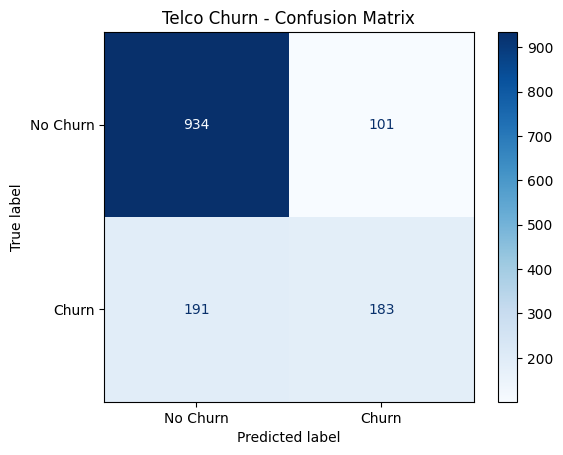

In [4]:
y_telco_pred = svm_telco.predict(X_telco_valid_scaled)
y_telco_score = svm_telco.decision_function(X_telco_valid_scaled)

roc_auc_telco = roc_auc_score(y_telco_valid, y_telco_score)
f1_telco = f1_score(y_telco_valid, y_telco_pred)
prec_telco = precision_score(y_telco_valid, y_telco_pred)
recall_telco = recall_score(y_telco_valid, y_telco_pred)

print(f"Test set ROC-AUC: {roc_auc_telco:.4f}")
print(f"F1 (Churn):       {f1_telco:.4f}\n")
print(classification_report(y_telco_valid, y_telco_pred,
                            target_names=['No Churn', 'Churn']))


ConfusionMatrixDisplay.from_predictions(y_telco_valid, y_telco_pred, display_labels=['No Churn', 'Churn'], cmap='Blues')
plt.title('Telco Churn - Confusion Matrix')
plt.show()

---
## 2. Dataset: E-Commerce Shopping

In [5]:
df_online = pd.read_csv(ECOM_PATH)
df_online_prep = pd.get_dummies(df_online, drop_first=True)

X_online = df_online_prep.drop(columns=['Revenue'])
y_online = df_online_prep['Revenue']

X_online_train, X_online_valid, y_online_train, y_online_valid = train_test_split(
    X_online, y_online, test_size=0.2, random_state=RANDOM_STATE, stratify=y_online
)

### Scaling and Model Training

In [6]:
online_scaler = preprocessing.StandardScaler().fit(X_online_train)
X_online_train_scaled = online_scaler.transform(X_online_train)
X_online_valid_scaled = online_scaler.transform(X_online_valid)

grid_online = GridSearchCV(SVC(kernel='rbf'), PARAM_GRID, cv=5)
grid_online.fit(X_online_train_scaled, y_online_train)
svm_online = grid_online.best_estimator_

cv_scores_online = cross_val_score(svm_online, X_online_train_scaled, y_online_train, cv=5)
cv_auc_scores_online = cross_val_score(svm_online, X_online_train_scaled, y_online_train, cv=5, scoring='roc_auc')

print(f"Best Parameter C: {grid_online.best_params_}")
print(f"Mean CV score: {cv_scores_online.mean():.4f}")
print(f"Mean CV ROC-AUC: {cv_auc_scores_online.mean():.4f} (+/- {cv_auc_scores_online.std():.4f})")

acc_online_train = svm_online.score(X_online_train_scaled, y_online_train) * 100
acc_online_valid = svm_online.score(X_online_valid_scaled, y_online_valid) * 100
print(f"Train Accuracy: {acc_online_train:.2f}%")
print(f"Valid Accuracy: {acc_online_valid:.2f}%")

Best Parameter C: {'C': 10}
Mean CV score: 0.8914
Mean CV ROC-AUC: 0.8614 (+/- 0.0133)


Train Accuracy: 93.27%
Valid Accuracy: 88.94%


### Model Evaluation

Test set ROC-AUC: 0.8589
F1 (Purchase):    0.6018

              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      2059
    Purchase       0.69      0.53      0.60       382

    accuracy                           0.89      2441
   macro avg       0.80      0.74      0.77      2441
weighted avg       0.88      0.89      0.88      2441



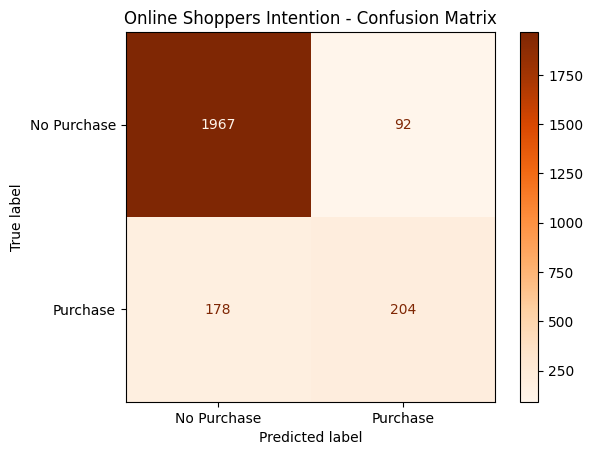

In [7]:
y_online_pred = svm_online.predict(X_online_valid_scaled)
y_online_score = svm_online.decision_function(X_online_valid_scaled)

roc_auc_online = roc_auc_score(y_online_valid, y_online_score)
f1_online = f1_score(y_online_valid, y_online_pred)
prec_online = precision_score(y_online_valid, y_online_pred)
recall_online = recall_score(y_online_valid, y_online_pred)

print(f"Test set ROC-AUC: {roc_auc_online:.4f}")
print(f"F1 (Purchase):    {f1_online:.4f}\n")
print(classification_report(y_online_valid, y_online_pred,
                            target_names=['No Purchase', 'Purchase']))

ConfusionMatrixDisplay.from_predictions(y_online_valid, y_online_pred, display_labels=['No Purchase', 'Purchase'], cmap='Oranges')
plt.title('Online Shoppers Intention - Confusion Matrix')
plt.show()

---
## 3. Dataset: Bank Marketing

In [8]:
df_bank = pd.read_csv(BANK_PATH)
df_bank = sort_bank_temporally(df_bank)  # chronological order for temporal split
df_bank_prep = pd.get_dummies(df_bank, drop_first=True)

X_bank = df_bank_prep.drop(columns=['y'])
y_bank = df_bank_prep['y']

# Temporal 80/20 split (no shuffling): Bank requires a chronological
# split to avoid look-ahead bias from the time-ordered macroeconomic features.
split_idx = int(len(X_bank) * 0.8)
X_bank_train, X_bank_valid = X_bank.iloc[:split_idx], X_bank.iloc[split_idx:]
y_bank_train, y_bank_valid = y_bank.iloc[:split_idx], y_bank.iloc[split_idx:]

### Scaling and Model Training

In [9]:
bank_scaler = preprocessing.StandardScaler().fit(X_bank_train)
X_bank_train_scaled = bank_scaler.transform(X_bank_train)
X_bank_valid_scaled = bank_scaler.transform(X_bank_valid)

# Bank uses TimeSeriesSplit (not a plain k-fold), consistent with the
# temporal train/test split above and with src/evaluation.py's split_mode='temporal'.
bank_cv = TimeSeriesSplit(n_splits=5)

grid_bank = GridSearchCV(SVC(kernel='rbf'), PARAM_GRID, cv=bank_cv)
grid_bank.fit(X_bank_train_scaled, y_bank_train)
svm_bank = grid_bank.best_estimator_

cv_scores_bank = cross_val_score(svm_bank, X_bank_train_scaled, y_bank_train, cv=bank_cv)
cv_auc_scores_bank = cross_val_score(svm_bank, X_bank_train_scaled, y_bank_train, cv=bank_cv, scoring='roc_auc')

print(f"Best Parameter C: {grid_bank.best_params_}")
print(f"Mean CV score: {cv_scores_bank.mean():.4f}")
print(f"Mean CV ROC-AUC: {cv_auc_scores_bank.mean():.4f} (+/- {cv_auc_scores_bank.std():.4f})")

acc_bank_train = svm_bank.score(X_bank_train_scaled, y_bank_train) * 100
acc_bank_valid = svm_bank.score(X_bank_valid_scaled, y_bank_valid) * 100
print(f"Train Accuracy: {acc_bank_train:.2f}%")
print(f"Valid Accuracy: {acc_bank_valid:.2f}%")

Best Parameter C: {'C': 1}
Mean CV score: 0.9282
Mean CV ROC-AUC: 0.8978 (+/- 0.0170)


Train Accuracy: 93.21%
Valid Accuracy: 86.92%


### Model Evaluation

Test set ROC-AUC: 0.8958
F1 (Sub):         0.5518

              precision    recall  f1-score   support

      No Sub       0.90      0.95      0.92      6861
         Sub       0.64      0.48      0.55      1375

    accuracy                           0.87      8236
   macro avg       0.77      0.71      0.74      8236
weighted avg       0.86      0.87      0.86      8236



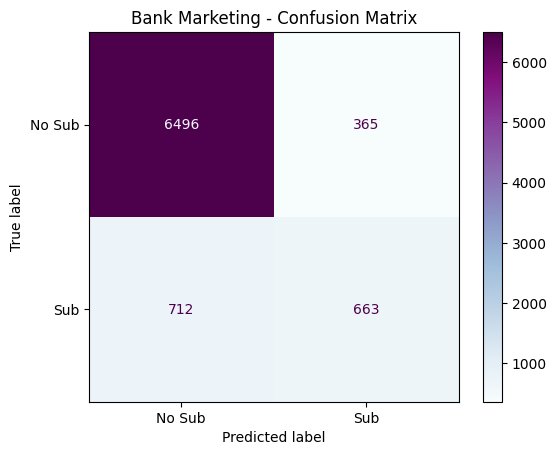

In [10]:
y_bank_pred = svm_bank.predict(X_bank_valid_scaled)
y_bank_score = svm_bank.decision_function(X_bank_valid_scaled)

roc_auc_bank = roc_auc_score(y_bank_valid, y_bank_score)
f1_bank = f1_score(y_bank_valid, y_bank_pred)
prec_bank = precision_score(y_bank_valid, y_bank_pred)
recall_bank = recall_score(y_bank_valid, y_bank_pred)

print(f"Test set ROC-AUC: {roc_auc_bank:.4f}")
print(f"F1 (Sub):         {f1_bank:.4f}\n")
print(classification_report(y_bank_valid, y_bank_pred,
                            target_names=['No Sub', 'Sub']))


ConfusionMatrixDisplay.from_predictions(y_bank_valid, y_bank_pred, display_labels=['No Sub', 'Sub'], cmap='BuPu')
plt.title('Bank Marketing - Confusion Matrix')
plt.show()

---
## Summary and Comparison

In [11]:
summary_data = {
    'Dataset': ['Telco Churn', 'Online Shoppers', 'Bank Marketing'],
    'C': [grid_telco.best_params_['C'], grid_online.best_params_['C'], grid_bank.best_params_['C']],
    'CV-AUC': [
        f"{cv_auc_scores_telco.mean():.4f} ± {cv_auc_scores_telco.std():.4f}",
        f"{cv_auc_scores_online.mean():.4f} ± {cv_auc_scores_online.std():.4f}",
        f"{cv_auc_scores_bank.mean():.4f} ± {cv_auc_scores_bank.std():.4f}",
    ],
    'Test-AUC': [f"{roc_auc_telco:.4f}", f"{roc_auc_online:.4f}", f"{roc_auc_bank:.4f}"],
    'F1':       [f"{f1_telco:.4f}", f"{f1_online:.4f}", f"{f1_bank:.4f}"],
    'Prec.':    [f"{prec_telco:.4f}", f"{prec_online:.4f}", f"{prec_bank:.4f}"],
    'Recall':   [f"{recall_telco:.4f}", f"{recall_online:.4f}", f"{recall_bank:.4f}"],
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
print("Model Performance Summary (Support Vector Machine, RBF-Kernel):")
display(summary_df)

Model Performance Summary (Support Vector Machine, RBF-Kernel):


,C,CV-AUC,Test-AUC,F1,Prec.,Recall
Dataset,,,,,,
Telco Churn,1,0.8055 ± 0.0136,0.7961,0.5562,0.6444,0.4893
Online Shoppers,10,0.8614 ± 0.0133,0.8589,0.6018,0.6892,0.5340
Bank Marketing,1,0.8978 ± 0.0170,0.8958,0.5518,0.6449,0.4822
